In [ ]:
# 딥 러닝 기초
# 기존 환자 데이터 이용하여 새로운 환자 예측

# 학습한 머신 러닝
# 지도 : KNN, 결정 트리, SVM 
# 비지도 : 군집, 차원축소

# 딥 러닝 : 예측 모델 적층
# 예를 들어 1차 함수 예측한 모델 생각했을 때
# y = ax + b / a랑 b를 수정하면 오차가 변경됨
# 그 오차를 줄이는 = 학습률
# H(x) = Wa + b / 가설함수 H

# 지도학습 -> 분류 -> 회귀
# Logistic Regression
# 키, 몸무게 로 계산한 y값을 class1, class2 로 분류
# 해결불가 예시 : 흡연량(수치)과 폐암 발병(0, 1)
# ㄴ 선형이 아닌 지수형식으로 = sigmoid 함수(관통할 수 있게 구부린)
# Logistic Regression : sigmoid 함수를 이용하여 분류하는 것!! f(g(x))
# o(z) = 1 / 1+e^(Wx+b) 형태

In [ ]:
# 로지스틱 회귀(Logistic Regression)
from sklearn.linear_model import LogisticRegression

# titanic data = Kaggle train.csv
import pandas as pd
df = pd.read_csv("train.csv")
df_tt = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()
X = df_tt.iloc[:, 1 : ]
y = df_tt.iloc[:, 0]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)

l_r = LogisticRegression(solver="lbfgs", C=1.0, max_iter=100)
# l_r.fit(X_train, y_train)
df_tt.info() # male, female 을 수치 데이터로 변환할 필요 있음
# 수치형 데이터를 학습할 때, 수치의 의미가 중요
# (레이블 인코딩을 하게 되면 결과가 좋지 않게 나옴 / 0, 1은 뭔가 가중치)
# Label Encoding -> Gender 컬럼 male 이면 0, female 1
# One-Hot Encoding 로 진행할 예정
# -> male 컬럼 만들어서 male 이면 1, female 이면 0
# -> female 컬럼 만들어서 female 이면 1, male이면 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


In [ ]:
# One-Hot Encoding
X_exam = X.copy()
X_exam # 연습용
# 1) male 컬럼 만들어서 Sex male 이면 1, 아니면 0
# 2) female 컬럼 만들어서 Sex female 이면 1, 아니면 0
X_exam["Male"] = X_exam["Sex"].apply(lambda x : 1 if x == "male" else 0)
X_exam["Female"] = X_exam["Sex"].apply(lambda x : 0 if x == "male" else 1)

X_exam2 = X.copy()
# X_exam2는 DataFrame이다
pd.get_dummies(X_exam2, dtype=int)
X_exam2 = X_exam2.dropna()
# 결측치가 있으면 또 학습이 안되니까 1원칙=일단 날리기 / 근데 또 y랑 안 맞아서 재진행
# X_train, X_test, y_train, y_test = train_test_split(X_exam2, y, random_state=20)
# l_r = LogisticRegression(solver="lbfgs", C=1.0, max_iter=100)
# l_r.fit(X_train, y_train)
X_exam2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  714 non-null    int64  
 1   Sex     714 non-null    object 
 2   Age     714 non-null    float64
 3   SibSp   714 non-null    int64  
 4   Parch   714 non-null    int64  
 5   Fare    714 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 39.0+ KB


In [ ]:
df = pd.read_csv("train.csv")
df_tt = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()
df_tt = df_tt.dropna() # 결측치 제거
df_tt = pd.get_dummies(df_tt, dtype=int)
X = df_tt.iloc[:, 1 : ]
y = df_tt.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)

l_r = LogisticRegression(solver="lbfgs", C=1.0, max_iter=200)
l_r.fit(X_train, y_train)

# 학습한 결과를 평가!!
from sklearn.metrics import accuracy_score # 정확도!
y_pred = l_r.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도: {accuracy * 100 : .3f}%")

정확도:  81.006%


In [ ]:
y_pred = l_r.predict(X_test)

from sklearn.metrics import confusion_matrix
c_m = confusion_matrix(y_test, y_pred, labels=[1,0])
# TP FN
# FP TN

# 수작업으로 구하기
[[TP, FN], [FP, TN]] = c_m

# 1) 정확도(Accuracy) : 얼마나 정답을 맞췄는지
# 생존한 사람을 생존했는지, 사망한 사람을 사망했는지 예측
# 분자 : TP + TN                    분모 : TP + FN + FP + TN
accuracy = (TP + TN) / (TP + FN + FP + TN)
print(f"정확도(Accuracy) : {accuracy * 100 : .2f}%")

# 2) 재현율(Recall) : 실제 정답을 얼마나 잘 맞췄는지
# 생존한 사람을 얼마나 잘 맞췄는지 예측
# 분자 : TP                         분모 : TP + FN
Recall = TP / (TP + FN)
print(f"재현율(Recall) : {Recall * 100 : .2f}%")

# 3) 정밀도(Precision) : 정답이라고 예측한 것 중에 맞춘 비율
# 생존했다고 예측한 것 중에 맞춘 비율
# 분자 : TP                         분모 : TP + FP
Precision = TP / (TP + FP)
print(f"정밀도(Precision) : {Precision * 100 : .2f}%")

# 재현율이 높다 -> 정확도가 낮더라도 암환자는 잘 찾아냄, 생존한 사람은 잘 찾아냄
# ㄴ진짜 정답을 틀리면 안되는 카테고리 : 의료, 재난

# 정밀도가 높다 -> 암환자로 분류한 것은 암환자일 확률이 높다
#               타이타닉 생존이라고 분류한 것은 생존했을 가능성이 높다

# 4) F1-Score : 정밀도와 재현율의 조화 평균 ( 2 / (1/a + 1/b) ) 
# 분자 : 2 * (Precision * Recall)   분모 : (Precision + Recall)
F1_Score = 2 * (Precision * Recall) / (Precision + Recall)
print(f"F1-Score : {F1_Score * 100 : .2f}%")

정확도(Accuracy) :  81.01%
재현율(Recall) :  70.13%
정밀도(Precision) :  83.08%
F1-Score :  76.06%
F1-Score2 :  76.06%


In [13]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
recall_l = recall_score(y_test, y_pred)
precision_l = precision_score(y_test, y_pred)
f1_score_l = f1_score(y_test, y_pred)

print(f"재현율(Recall_library) : {recall_l * 100 : .2f}%")
print(f"정밀도(Precision_library) : {precision_l * 100 : .2f}%")
print(f"F1-Score_library : {f1_score_l * 100 : .2f}%")

print(classification_report(y_test, y_pred))

재현율(Recall_library) :  70.13%
정밀도(Precision_library) :  83.08%
F1-Score_library :  76.06%
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       102
           1       0.83      0.70      0.76        77

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# 평가 지표 관련
# Confusion matrix (혼돈 행렬, 오차 행렬)

# ex. 표본 100명 - 암 5명 & 정상 95명
# 모델 : 누가 오든 정상이라고 말함 -> 정확도: 95%
# 즉, 정확도만이 평가지표로서 사용되는 건 아니다!!

# 첨부 이미지 참고 -> TP FN / FP TN 으로 구분 [암환자 -> True]
# Accuracy (정확도) = TP + TN / TP + TN + FP + FN -> 전체 중에 정확히 맞춘 비율
# 전부 정상이라 예측했으니 TN = 95 / FN = 5 이니까 "95%"

# Recall (재현율) = TP / TP + FN -> 실제 정답 중에 정확히 맞춘 비율
# ㄴ True&False 구분이 중요 / 암 환자를 맞추는 모델이니까  0/5라 "0%"

# Precision (정밀도) = TP / TP + FP -> 정답으로 예측한 것 중에서 실제로 맞춘 비율
# ㄴ 기존 가정은 전부 정상이라 했으니 0/0+0 -> 극단 케이스라 정의 불가(혹은 0%)

# F1-Score (정밀도와 재현율의 "조화 평균") = 2 / (1/a + 1/b) 를 풀어쓴거
# 2 * (Precision * Recall) / (Precision + Recall)

In [4]:
# 오차를 수정해서 선형 회귀 W, b를 구해보자
import numpy as np
X = np.array([2, 4, 6, 8])        # 공부한 시간
y = np.array([81, 93, 91, 97])    # 성적
# y와 X의 관계?
import matplotlib.pyplot as plt
# plt.plot(X, y, marker="o")
# plt.show()

# y = ax + b
X_mean = X.mean()
y_mean = y.mean()
분자 = np.sum((X-X_mean)*(y-y_mean))
분모 = np.sum((X-X_mean)**2)
a = 분자 / 분모 # 2.3
b = y_mean - a * X_mean # 79
def model(X_input):
    return a * X_input + b

# a, b 를 구하기 위해
# a = 3, b = 50 -> 내 맘대로 정한 이후에
# 실제 데이터 -> 예측값(y_pred)
# 실제값(y_test) - 예측값(y_pred) 사이의 차이를 보고
# 차이를 줄이는 방향으로 a, b를 수정해보자

# 오차를 어떤걸 쓸지?
# MAE(절댓값 차이 오차), MSE(제곱 차이 평균), RMSE(제곱 차이 평균 루트)
def model_custom(X_input, a, b):
    return a * X_input + b

# X를 model 로 예측한 MSE
def MSE_model(X, y, a, b):
    return np.average((model(X) - y)**2)

def MSE_model_custom(X, y, a, b):
    return np.average(((a * X + b) - y ) **2)


# 오차에 대한 2차함수를 구해서
# 기울기가 양수면 a를 음수 방향(줄여서)
# 기울기가 음수면 a를 양수 방향(큰 점으로)
# = 학습률 [얼마나 움직이나 - 너무 크면 찾지 못하고 발산]
n = len(X)

# a로 편미분한 결과
a, b = 7, 51
diff_a = 0
for x_i, y_i in zip(X, y):
    diff_a += (-2 / n) * x_i * (y_i - (a * x_i + b))
# b로 편미분한 결과
diff_b = 0
diff_b = (-2 / n) * sum((y_i - (a * x_i + b)) for x_i, y_i in zip(X, y))
print(diff_a, diff_b)
print(MSE_model_custom(X, y, 7, 51))
print(MSE_model_custom(X, y, 2.3, 79))

2.0 -9.0
139.0
8.299999999999985


In [7]:
# 학습 (1000번 학습해보자)
# 딥러닝스러운 첫 번째 코드

# 경사 하강법
# 편미분 값의 기울기를 보고 오차를 수정해나가는 방식
a, b = 0, 0     # 초반 값 모름
lr = 0.1        # 학습률(learning rate)
epochs = 1000   # 학습 진행 횟수
n = len(X)
for i in range(1, epochs + 1):
    diff_a = (-2 / n) * sum(x_i * (y_i - (a * x_i + b)) for x_i, y_i in zip(X, y))
    diff_b = (-2 / n) * sum((y_i - (a * x_i + b)) for x_i, y_i in zip(X, y))
    # 편미분 값의 기울기 양수 -> 음의 방향, 음수 -> 양의 방향
    a = a - lr * diff_a # lr 만큼 가중치를 가지고 이동
    b = b - lr * diff_b
    if i % 100 == 0:
        print(f"a, b : {a, b}")
# lr 이 크면 발산, 너무 작으면 과도한 미세 조정

a, b : (np.float64(-3.221294246440665e+72), np.float64(-5.397997826063135e+71))
a, b : (np.float64(-6.865731400959517e+143), np.float64(-1.150506608257326e+143))
a, b : (np.float64(-1.463333184238183e+215), np.float64(-2.4521415130119667e+214))
a, b : (np.float64(-3.1188869517869536e+286), np.float64(-5.226391536285496e+285))
a, b : (np.float64(nan), np.float64(nan))
a, b : (np.float64(nan), np.float64(nan))
a, b : (np.float64(nan), np.float64(nan))
a, b : (np.float64(nan), np.float64(nan))
a, b : (np.float64(nan), np.float64(nan))
a, b : (np.float64(nan), np.float64(nan))


C:\Users\kccistc\AppData\Local\Temp\ipykernel_17268\1576388874.py:11: RuntimeWarning: overflow encountered in scalar multiply
  diff_a = (-2 / n) * sum(x_i * (y_i - (a * x_i + b)) for x_i, y_i in zip(X, y))
C:\Users\kccistc\AppData\Local\Temp\ipykernel_17268\1576388874.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  a = a - lr * diff_a # lr 만큼 가중치를 가지고 이동


In [ ]:
# 다중 선형 회귀
# 강력한 경사하강법 사용하여
X1 = X.copy()               # 학습 시간
X2 = np.array([0, 4, 2, 3]) # 과외 횟수
# print(X1, X2, y)
# y = a1 * X1 + a2 * X2 + b
a1, a2, b = 0, 0, 0
lr = 0.01
epochs = 1000
n = len(X)

for i in range(1, epochs + 1):
    y_pred = a1 * X1 + a2 * X2 + b  # 예측값
    error = y - y_pred              # 오차
    # diff_a = (-2 / n) * sum(x_i * (y_i - (a * x_i + b)) for x_i, y_i in zip(X, y))
    diff_a1 = (-2 / n) * sum(x_i * (e) for x_i, e in zip(X1, error))
    diff_a2 = (-2 / n) * sum(x_i * (e) for x_i, e in zip(X2, error))
    diff_b = (-2 / n) * sum(e for e in error)

    if i % 100 == 0:
        print(f"{a1 :.2f} * x1 + {a2 :.2f} * x2 + {b :.2f}")

    a1 = a1 - lr * diff_a1
    a2 = a2 - lr * diff_a2
    b = b - lr * diff_b

# 알아야 하는 포인트***
# * 선형 회귀에서 오차를 수정할 때, 편미분 한 값의 반댓방향으로 이동한다
#  -> 경사하강법이라고 부른다
# 얼마나 가중치를 두고 이동할건지 -> 학습률(learning rate)

9.56 * x1 + 5.04 * x2 + 22.57
7.36 * x1 + 4.31 * x2 + 37.62
5.77 * x1 + 3.76 * x2 + 48.57
4.60 * x1 + 3.36 * x2 + 56.55
3.76 * x1 + 3.07 * x2 + 62.35
3.14 * x1 + 2.85 * x2 + 66.57
2.70 * x1 + 2.70 * x2 + 69.64
2.37 * x1 + 2.59 * x2 + 71.88
2.13 * x1 + 2.50 * x2 + 73.51
1.96 * x1 + 2.44 * x2 + 74.69


In [ ]:
# 그려보자
# 3차원 그릴 캔버스
fig = plt.figure()
graph = fig.add_subplot(111, projection="3d")
graph.scatter(X1, X2, y)
plt.show()

In [14]:
%pip install tensorflow
%pip install keras

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/331.7 MB 5.6 MB/s eta 0:01:00
   ---------------------------------------- 1.0/331.7 MB 3.6 MB/s eta 0:01:33
   - -------------------------------------- 9.4/331.7 MB 15.1 MB/s eta 0:00:22
   --- ------------------------------------ 27.8/331.7 MB 33.9 MB/s eta 0:00:09
   ----- ---------------------------------- 44.0/331.7 MB 45.2 MB/s eta 0:00:07
   ------- -------------------------------- 59.8/331.7 MB 47.6 MB/s eta 0:00:06
   -------- ------------------------------- 67.1/331.7 MB 51.0 MB/s eta 0:00:06
   -------- ------------------------------- 71.3/331.7 MB 42.5 MB/s eta 0:00:07
   ----------- ---------------------------- 92.3/331.7 MB 49.1 MB/s eta 0:00:05
   ------------ -------------------------- 108.5/331.7 MB 51.7 MB/s eta 0:00:05
   ------------- ------------------------- 111.1/331.7 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
data = np.loadtxt("https://github.com/nayeho/robot/raw/refs/heads/main/data/ThoraricSurgery3.csv", delimiter=",")
data[0:5, 16] # 17번째 컬럼이 생존여부 1 : 생존, 0 : 사망

array([0., 0., 0., 0., 1.])

In [10]:
X = data[:, :16]
y = data[:, 16]
model = Sequential() # 쌓을 층들이 존재하는 공간
# 은닉층으로 쓸 node 갯수, 들어올 feature 갯수, 활성함수
model.add(Dense(30, input_dim=16, activation="relu"))
model.add(Dense(20, input_dim=30, activation="relu"))
# 그 전 단계가 30개여서 맞춰주는게 좋음
model.add(Dense(1, activation="sigmoid"))

# 딥 러닝 모델을 설정!!
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X, y, epochs=100, batch_size=16)

# 첫 딥 러닝 끝
# 1) 데이터 가져오기 -> 전처리 및 분류까지
# 2) model = Sequential() 해서 층을 쌓기

Epoch 1/100


C:\Users\kccistc\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.8511 - loss: 0.4526 
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.8511 - loss: 0.4426
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.8511 - loss: 0.4318
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - accuracy: 0.8511 - loss: 0.4263
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.8511 - loss: 0.4247
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.8511 - loss: 0.4265
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8511 - loss: 0.4310
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8511 - loss: 0.4167
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.8511 - loss: 0.4189
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8511 - loss: 0.4210 
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.8511 - loss: 0.4258
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step

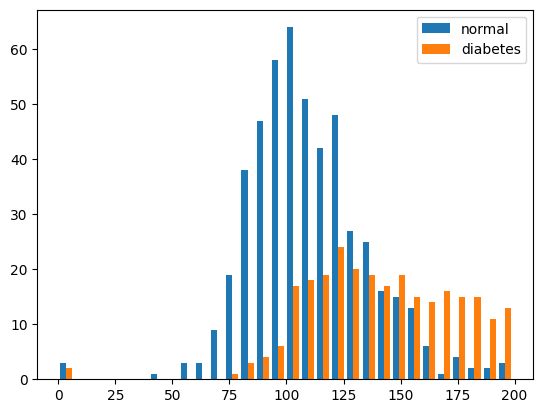

In [22]:
# 다른 데이터를 통해 딥 러닝 해보자
import pandas as pd
data_indians = pd.read_csv("https://github.com/nayeho/robot/raw/refs/heads/main/data/pima-indians-diabetes3.csv")

# 정상과 당뇨 여부를 딥 러닝 모델로
data_indians["diabetes"].value_counts() # 1 : 당뇨, 0 : 당뇨 아님
data_indians.describe()                 # 수치형 데이터 통계 정보 제공
data_indians.corr()                     # 상관 관계 계수 확인

# 히스토그램 시각화
import matplotlib.pyplot as plt
his_x_1 = data_indians.plasma[data_indians.diabetes == 0] # 당뇨가 없는 사람들의 plasma를 X
his_x_2 = data_indians.plasma[data_indians.diabetes == 1] # 당뇨가 있는 사람들의 plasma를 X
plt.hist(x=[his_x_1, his_x_2], bins=30, label=["normal", "diabetes"])
plt.legend()

In [28]:
# 두 번째 딥 러닝
# data_indians의 feature는 8개 + diabetes 로 구성
X = data_indians.iloc[:, : 8]
y = data_indians.iloc[:, 8]
model = Sequential()
model.add(Dense(64, input_dim=8, activation="relu", name="layer_1"))
model.add(Dense(92, input_dim=64, activation="relu", name="layer_2"))
model.add(Dense(1, input_dim=92, activation="sigmoid", name="layer_3"))
# model.summary()

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X, y, epochs=50, batch_size=16, verbose=False)

C:\Users\kccistc\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 평가 지표 - 이번엔 epochs 50으로
print(np.average(history.history["accuracy"])) # 100번 학습 동안 정확도 평균
print(np.max(history.history["accuracy"]))     # 100번 학습 동안 최고 정확도


0.7039062464237213
0.76953125


In [1]:
# 세 번째 딥러닝
import pandas as pd
df = pd.read_csv("train.csv")
df_tt = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()

# 1) 전처리 : 결측치(NaN) dropna
# 2) 범주형 데이터인 Sex -> One-Hot Encoding
# 3) X, y 를 iloc 슬라이싱
#  -> y : Survived, X : 나머지 컬럼
# 4) Sequential() 통해 층을 쌓을 model 인스턴스 만들기
# 5) Dense()를 통해 원하는 만큼 층 쌓기
# 6) 단, 마지막 층은 output 1, 활성화 함수 sigmoid로 해주세요
# 7) 생존 혹은 사망 -> 이항분류(binary_crossentropyh) 학습
# 8) epochs, batch_size 원하는 만큼 파라미터 설정
# 9) 학습!!
# 10) 정확도도 확인해보세요


In [3]:
# 1) 전처리 : 결측치(NaN) dropna
# 2) 범주형 데이터인 Sex -> One-Hot Encoding
# 3) X, y 를 iloc 슬라이싱
#  -> y : Survived, X : 나머지 컬럼

df_tt = df_tt.dropna()
df_tt = pd.get_dummies(df_tt, dtype=int)
X = df_tt.iloc[:, 1 : ]
y = df_tt.iloc[:, 0]
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,3,22.0,1,0,7.2500,0,1
1,1,38.0,1,0,71.2833,1,0
2,3,26.0,0,0,7.9250,1,0
3,1,35.0,1,0,53.1000,1,0
4,3,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...
885,3,39.0,0,5,29.1250,1,0
886,2,27.0,0,0,13.0000,0,1
887,1,19.0,0,0,30.0000,1,0
889,1,26.0,0,0,30.0000,0,1


In [10]:
# 4) Sequential() 통해 층을 쌓을 model 인스턴스 만들기
# 5) Dense()를 통해 원하는 만큼 층 쌓기
# 6) 단, 마지막 층은 output 1, 활성화 함수 sigmoid로 해주세요
# 7) 생존 혹은 사망 -> 이항분류(binary_crossentropyh) 학습
# 8) epochs, batch_size 원하는 만큼 파라미터 설정
# 9) 학습!!
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(28, input_dim=7, activation="relu", name="layer_1"))
model.add(Dense(50, input_dim=28, activation="relu", name="layer_2"))
model.add(Dense(1, input_dim=50, activation="sigmoid", name="layer_3"))

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X, y, epochs=200, batch_size=16)

Epoch 1/200


C:\Users\kccistc\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.5756 - loss: 1.1374 
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.6751 - loss: 0.6305
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.6639 - loss: 0.6221
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - accuracy: 0.6765 - loss: 0.6044
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.6849 - loss: 0.6183
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.7003 - loss: 0.5866
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - accuracy: 0.6989 - loss: 0.5908
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.7185 - loss: 0.5594
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.7297 - loss: 0.5467
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - accuracy: 0.7367 - loss: 0.5408
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.7325 - loss: 0.5334
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/ste

In [11]:
# 10) 정확도도 확인해보세요
import numpy as np
print(f"정확도 : {np.average(history.history['accuracy']) *100 :.4f}%")
print(f"최대값 : {np.max(history.history['accuracy']) *100: .4f}%")


정확도 : 79.8088%
최대값 :  83.0532%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

data_indians = pd.read_csv("https://github.com/nayeho/robot/raw/refs/heads/main/data/pima-indians-diabetes3.csv")


C:\Users\kccistc\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'
